In [142]:
#evaluation of different consensus sequences as query
#author: Sheng-Kai Hsu
#created: 2024.03.25
#last edited: 2024.06.06
rm(list=ls())

In [143]:
library(rtracklayer)
library(Biostrings)
library(limma)
library(scales)
library(LSD)
library(parallel)

In [144]:
queryFaPv = readAAStringSet("/workdir/sh2246/p_phyloGWAS/output/Pv-672_v3.0_peptide.fa")
queryFaPv_length=width(queryFaPv)
names(queryFaPv_length)=names(queryFaPv)

queryFaHelixerOG = readAAStringSet("/workdir/sh2246/p_phyloGWAS/output/HelixerOG_ancSeq_gapRemoved.fa")
queryFaHelixerOG_length=width(queryFaHelixerOG)
names(queryFaHelixerOG_length)=names(queryFaHelixerOG)
queryFaPoaceaeHelixerOG = readAAStringSet("/workdir/sh2246/p_phyloGWAS/output/poaceaeHelixerOG_ancSeq_gapRemoved.fa")
queryFaPoaceaeHelixerOG_length=width(queryFaPoaceaeHelixerOG)
names(queryFaPoaceaeHelixerOG_length)=names(queryFaPoaceaeHelixerOG)

queryFaEggNOG = readAAStringSet("/workdir/sh2246/p_phyloGWAS/output/eggNOGv5_consensus.fa")
queryFaEggNOG_length=width(queryFaEggNOG)
names(queryFaEggNOG_length)=names(queryFaEggNOG)


In [145]:
gff_Pv_flist = list.files("/workdir/sh2246/p_phyloGWAS/output/queryComparison/miniProt_Pv",full.names = T)
gff_Pv_list = mclapply(gff_Pv_flist,function(x){
    readGFF(x)
},mc.cores = 20)

gff_helixerOG_flist = list.files("/workdir/sh2246/p_phyloGWAS/output/queryComparison/miniProt_helixerOG",full.names = T)
gff_helixerOG_list = mclapply(gff_helixerOG_flist,function(x){
    readGFF(x)
},mc.cores = 20)
gff_poaceaehelixerOG_flist = list.files("/workdir/sh2246/p_phyloGWAS/output/queryComparison/miniProt_poaceaeHelixerOG",full.names = T)
gff_poaceaehelixerOG_list = mclapply(gff_poaceaehelixerOG_flist,function(x){
    readGFF(x)
},mc.cores = 20)

gff_eggNOG_flist = list.files("/workdir/sh2246/p_phyloGWAS/output/queryComparison/miniProt_eggNOG",full.names = T)
gff_eggNOG_list = mclapply(gff_eggNOG_flist,function(x){
    readGFF(x)
},mc.cores = 20)


In [146]:
head(gff_Pv_list[[1]])

DataFrame with 6 rows and 18 columns
       seqid   source       type     start       end     score      strand
    <factor> <factor>   <factor> <integer> <integer> <numeric> <character>
1 ctg_77902  miniprot mRNA          601080    601754       993           +
2 ctg_77902  miniprot CDS           601080    601751       993           +
3 ctg_77902  miniprot stop_codon    601752    601754         0           +
4 ctg_372823 miniprot mRNA           95643     98978      2101           -
5 ctg_372823 miniprot CDS            98880     98978       158           -
6 ctg_372823 miniprot CDS            98699     98794       161           -
      phase          ID        Rank    Identity    Positive
  <integer> <character> <character> <character> <character>
1        NA    MP000001           1      0.8533      0.9022
2         0          NA           1      0.8533          NA
3         0          NA           1          NA          NA
4        NA    MP000002           1      0.8993      0.9306
5  

In [147]:
queryStat_Pv_list = mclapply(gff_Pv_list,function(x){
    tmp = x[x[,3]=="mRNA"&x[,10]==1,]
    queryStat = strsplit2(tmp$Target," ")
    queryStat = as.data.frame(queryStat)
    colnames(queryStat) = c("query","start","end")
    queryStat$range = as.numeric(queryStat[,3])-as.numeric(queryStat[,2])+1
    return(queryStat)
},mc.cores = 20)

queryStat_helixerOG_list = mclapply(gff_helixerOG_list,function(x){
    tmp = x[x[,3]=="mRNA"&x[,10]==1,]
    queryStat = strsplit2(tmp$Target," ")
    queryStat = as.data.frame(queryStat)
    colnames(queryStat) = c("query","start","end")
    queryStat$range = as.numeric(queryStat[,3])-as.numeric(queryStat[,2])+1
    return(queryStat)
},mc.cores = 20)
queryStat_poaceaehelixerOG_list = mclapply(gff_poaceaehelixerOG_list,function(x){
    tmp = x[x[,3]=="mRNA"&x[,10]==1,]
    queryStat = strsplit2(tmp$Target," ")
    queryStat = as.data.frame(queryStat)
    colnames(queryStat) = c("query","start","end")
    queryStat$range = as.numeric(queryStat[,3])-as.numeric(queryStat[,2])+1
    return(queryStat)
},mc.cores = 20)

queryStat_eggNOG_list = mclapply(gff_eggNOG_list,function(x){
    tmp = x[x[,3]=="mRNA"&x[,10]==1,]
    queryStat = strsplit2(tmp$Target," ")
    queryStat = as.data.frame(queryStat)
    colnames(queryStat) = c("query","start","end")
    queryStat$range = as.numeric(queryStat[,3])-as.numeric(queryStat[,2])+1
    return(queryStat)
},mc.cores = 20)

In [150]:
# query coverage
qcov_Pv_list = mclapply(queryStat_Pv_list,function(x){
    qcov=c()
    for (i in unique(x[,1])){
      qcov=c(qcov,x[x[,1]==i,4]/queryFaPv_length[i])
    }
    return(qcov)
},mc.cores = 20)

qcov_helixerOG_list = mclapply(queryStat_helixerOG_list,function(x){
    qcov=c()
    for (i in unique(x[,1])){
      qcov=c(qcov,x[x[,1]==i,4]/queryFaHelixerOG_length[i])
    }
    return(qcov)
},mc.cores = 20)
qcov_poaceaehelixerOG_list = mclapply(queryStat_poaceaehelixerOG_list,function(x){
    qcov=c()
    for (i in unique(x[,1])){
      qcov=c(qcov,x[x[,1]==i,4]/queryFaPoaceaeHelixerOG_length[i])
    }
    return(qcov)
},mc.cores = 20)

qcov_eggNOG_list = mclapply(queryStat_eggNOG_list,function(x){
    qcov=c()
    for (i in unique(x[,1])){
      qcov=c(qcov,x[x[,1]==i,4]/queryFaEggNOG_length[i])
    }
    return(qcov)
},mc.cores = 20)


In [151]:
sapply(qcov_Pv_list,length)

[1] 39519 40612 41065 41210 40149 41175 37322 40358 39732 40312 39782 40785
[13] 40413 40180 39874 38078 39523 38990 40211 40195 39927 40417 40300 39602
[25] 40899 39901 39650 39514 39642 39629 39856 39814 39710 39638 39701 40208
[37] 40105 39994 40742 40242 38686 38663 38647 38632 38633 38722 38606 38647
[49] 38572 38543

In [152]:
qcov_Pv_mat = c()
for (i in 1:length(qcov_Pv_list)){
    qcov_Pv_mat = cbind(qcov_Pv_mat,qcov_Pv_list[[i]][names(queryFaPv_length)])
}
qcov_helixerOG_mat = c()
for (i in 1:length(qcov_helixerOG_list)){
    qcov_helixerOG_mat = cbind(qcov_helixerOG_mat,qcov_helixerOG_list[[i]][names(queryFaHelixerOG_length)])
}
qcov_poaceaehelixerOG_mat = c()
for (i in 1:length(qcov_poaceaehelixerOG_list)){
    qcov_poaceaehelixerOG_mat = cbind(qcov_poaceaehelixerOG_mat,qcov_helixerOG_list[[i]][names(queryFaPoaceaeHelixerOG_length)])
}
qcov_eggNOG_mat = c()
for (i in 1:length(qcov_eggNOG_list)){
    qcov_eggNOG_mat = cbind(qcov_eggNOG_mat,qcov_eggNOG_list[[i]][names(queryFaEggNOG_length)])
}


In [153]:
qcov_Pv_mat[is.na(qcov_Pv_mat)] = 0
qcov_helixerOG_mat[is.na(qcov_helixerOG_mat)] = 0
qcov_poaceaehelixerOG_mat[is.na(qcov_poaceaehelixerOG_mat)] = 0
qcov_eggNOG_mat[is.na(qcov_eggNOG_mat)] = 0

In [154]:
rownames(qcov_Pv_mat) = names(queryFaPv_length)
rownames(qcov_helixerOG_mat) = names(queryFaHelixerOG_length)
rownames(qcov_poaceaehelixerOG_mat) = names(queryFaPoaceaeHelixerOG_length)
rownames(qcov_eggNOG_mat) = names(queryFaEggNOG_length)

In [202]:
numTaxaPerOG_Pv = apply(qcov_Pv_mat,1,function(x) sum(x>.7))
numTaxaPerOG_helixerOG = apply(qcov_helixerOG_mat,1,function(x) sum(x>.7))
numTaxaPerOG_poaceaehelixerOG = apply(qcov_poaceaehelixerOG_mat,1,function(x) sum(x>.7))
numTaxaPerOG_eggNOG = apply(qcov_eggNOG_mat,1,function(x) sum(x>.7))

In [203]:
numTaxaPerOG_Pv = numTaxaPerOG_Pv[!duplicated(gsub("\\..","",names(numTaxaPerOG_Pv)))]

In [192]:
poaceaeFilterV2 = read.table("/workdir/sh2246/p_phyloGWAS/output/poaceaeHelixerOG_filtered_v2.txt")[,1]

In [193]:
numTaxaPerOG_poaceaehelixerOG = numTaxaPerOG_poaceaehelixerOG[poaceaeFilterV2]

In [194]:
length(numTaxaPerOG_Pv)
length(numTaxaPerOG_helixerOG)
length(numTaxaPerOG_poaceaehelixerOG)
length(numTaxaPerOG_eggNOG)

[1] 35842

[1] 29534

[1] 20037

[1] 31003

In [204]:
bpDat = rbind(table(numTaxaPerOG_Pv),table(numTaxaPerOG_helixerOG),
              table(numTaxaPerOG_poaceaehelixerOG),table(numTaxaPerOG_eggNOG))
bpDat = bpDat/rowSums(bpDat)

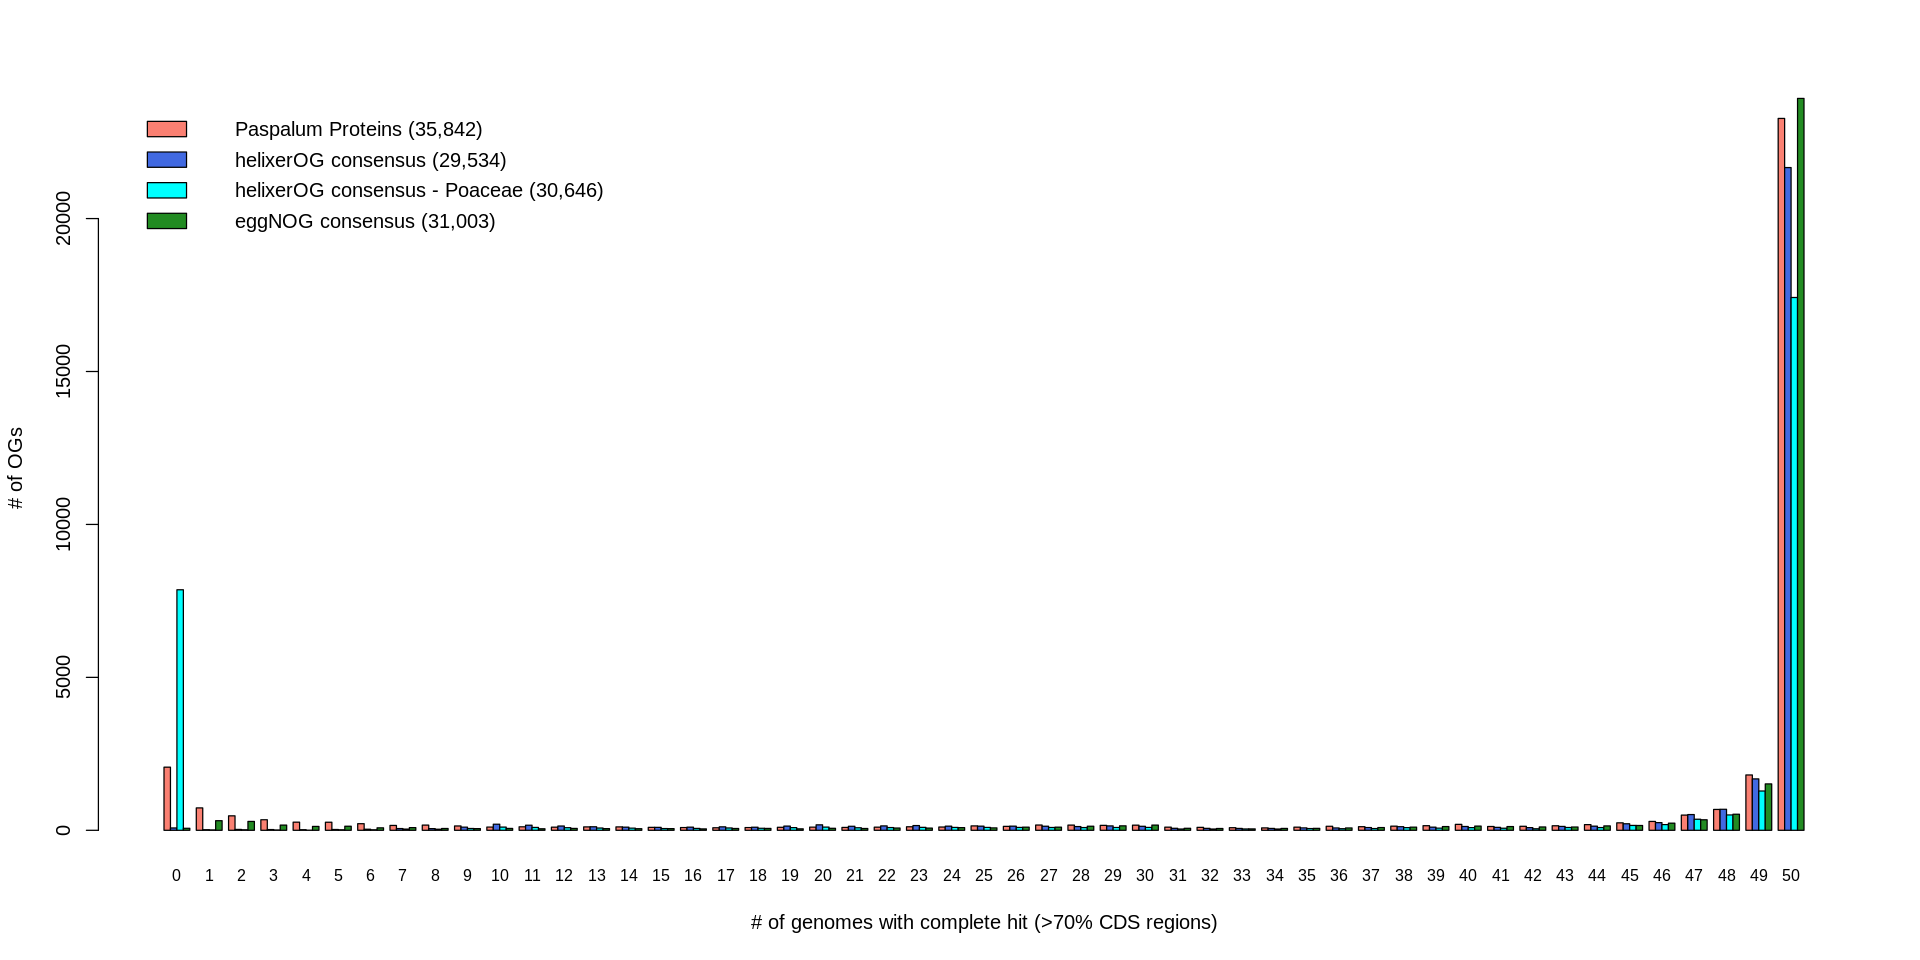

In [207]:
options(repr.plot.width=16, repr.plot.height=8)
barplot(rbind(table(numTaxaPerOG_Pv),table(numTaxaPerOG_helixerOG),
              table(numTaxaPerOG_poaceaehelixerOG),table(numTaxaPerOG_eggNOG)),beside = T,
        xlab = "# of genomes with complete hit (>70% CDS regions)",ylab = "# of OGs",
       col = c("salmon","royalblue","cyan","forestgreen"),cex.name = .8,args.legend = list(bty = 'n',x = "topleft"),
        legend.text = c("Paspalum Proteins (35,842)","helixerOG consensus (29,534)"
                        ,"helixerOG consensus - Poaceae (30,646)","eggNOG consensus (31,003)"))

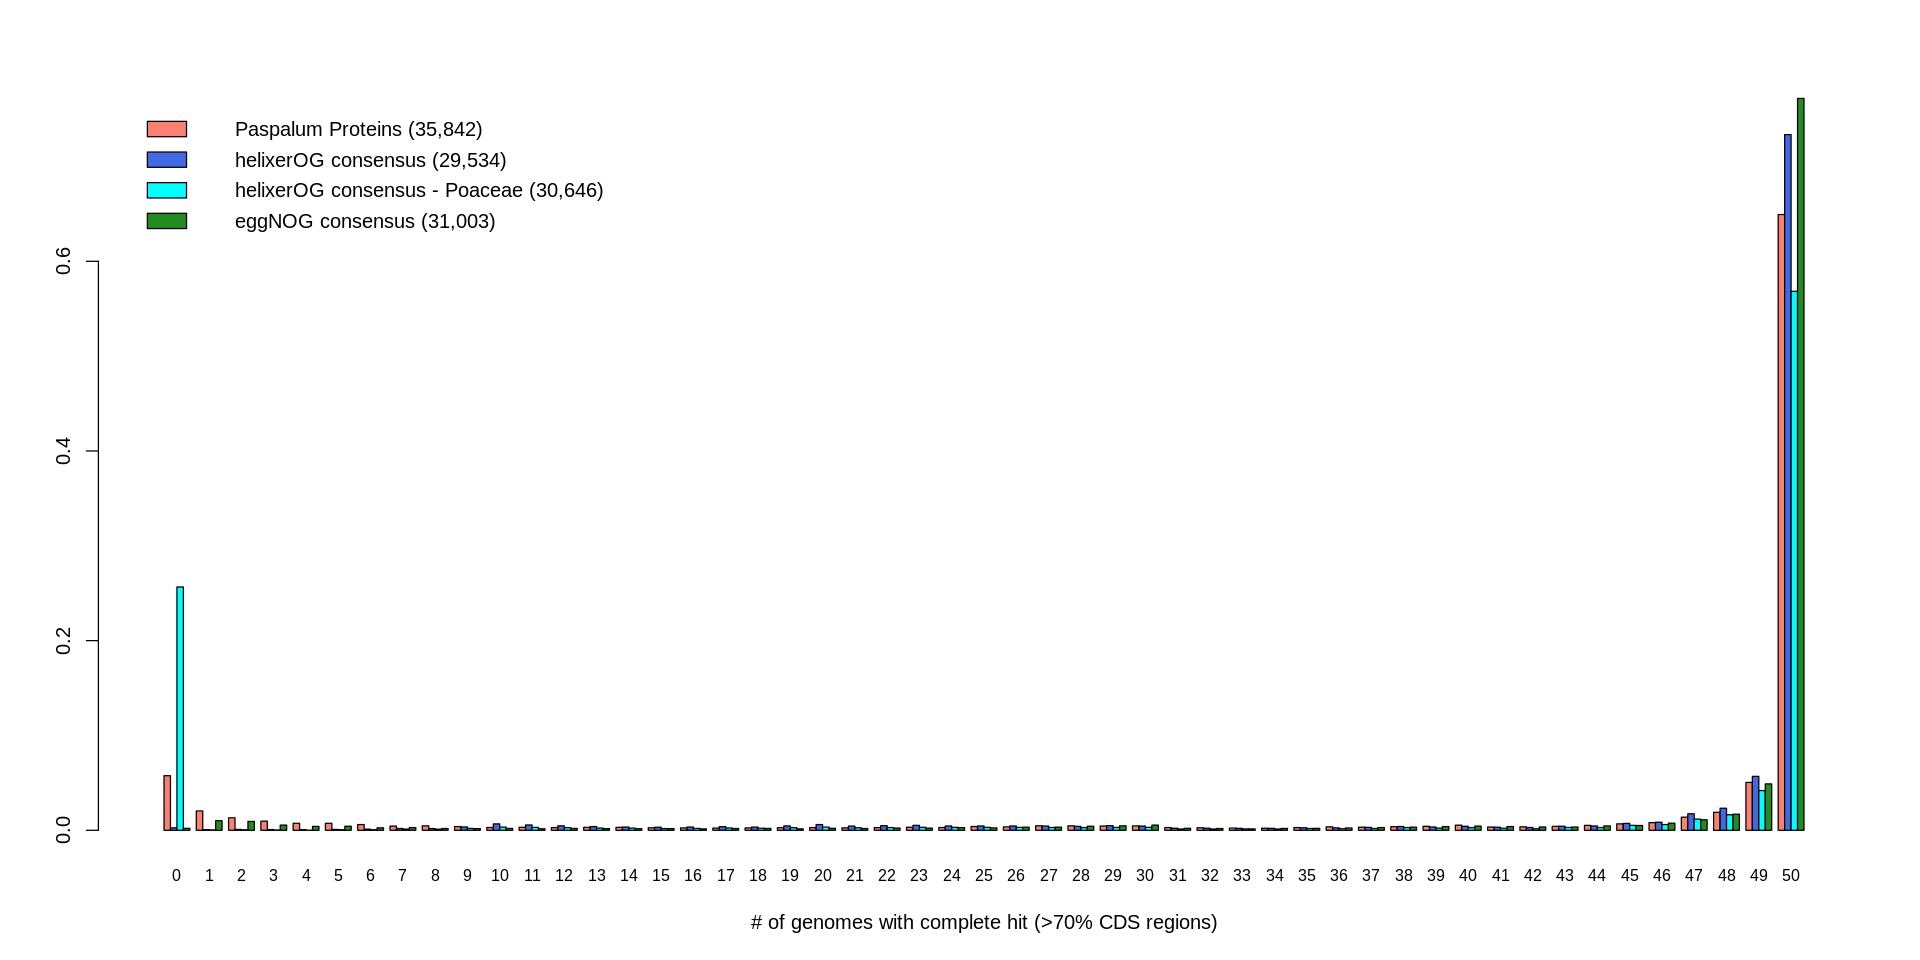

In [206]:
options(repr.plot.width=16, repr.plot.height=8)
barplot(bpDat,beside = T,
        xlab = "# of genomes with complete hit (>70% CDS regions)",
       col = c("salmon","royalblue","cyan","forestgreen"),cex.name = .8,args.legend = list(bty = 'n',x = "topleft"),
        legend.text = c("Paspalum Proteins (35,842)","helixerOG consensus (29,534)"
                        ,"helixerOG consensus - Poaceae (30,646)","eggNOG consensus (31,003)"))

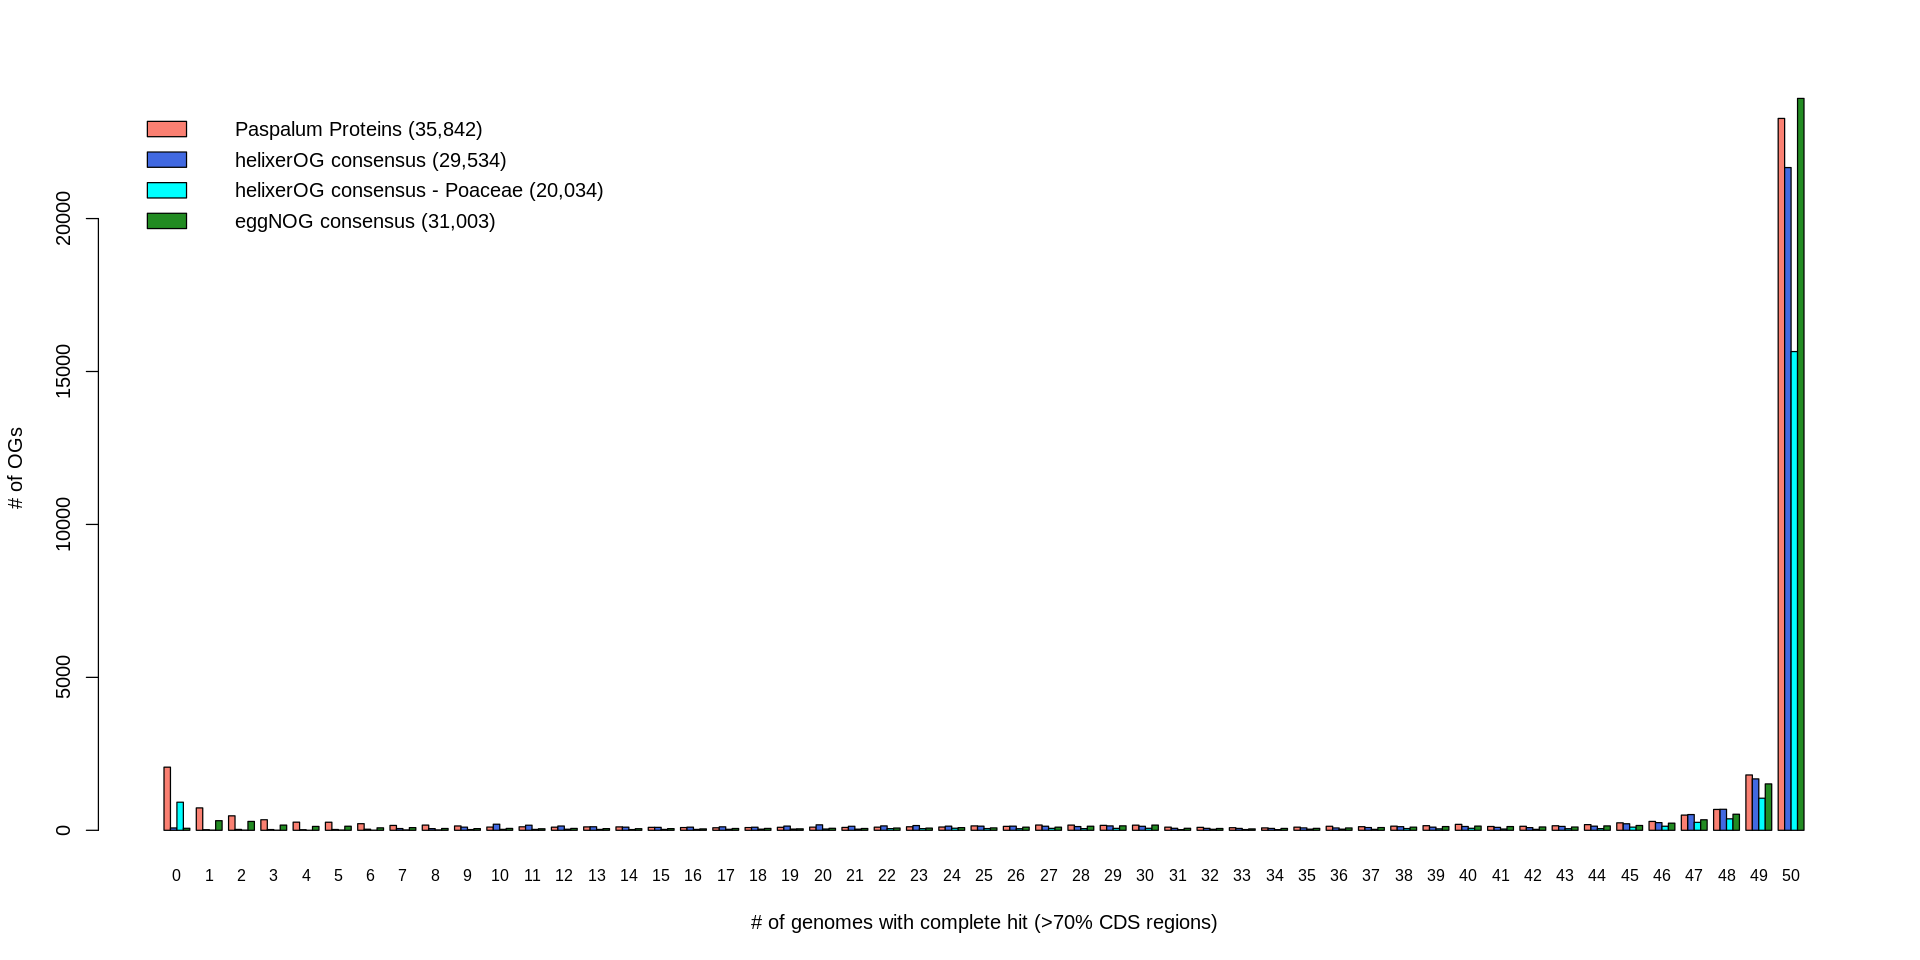

In [200]:
options(repr.plot.width=16, repr.plot.height=8)
barplot(rbind(table(numTaxaPerOG_Pv),table(numTaxaPerOG_helixerOG),
              table(numTaxaPerOG_poaceaehelixerOG),table(numTaxaPerOG_eggNOG)),beside = T,
        xlab = "# of genomes with complete hit (>70% CDS regions)",ylab = "# of OGs",
       col = c("salmon","royalblue","cyan","forestgreen"),cex.name = .8,args.legend = list(bty = 'n',x = "topleft"),
        legend.text = c("Paspalum Proteins (35,842)","helixerOG consensus (29,534)"
                        ,"helixerOG consensus - Poaceae (20,034)","eggNOG consensus (31,003)"))

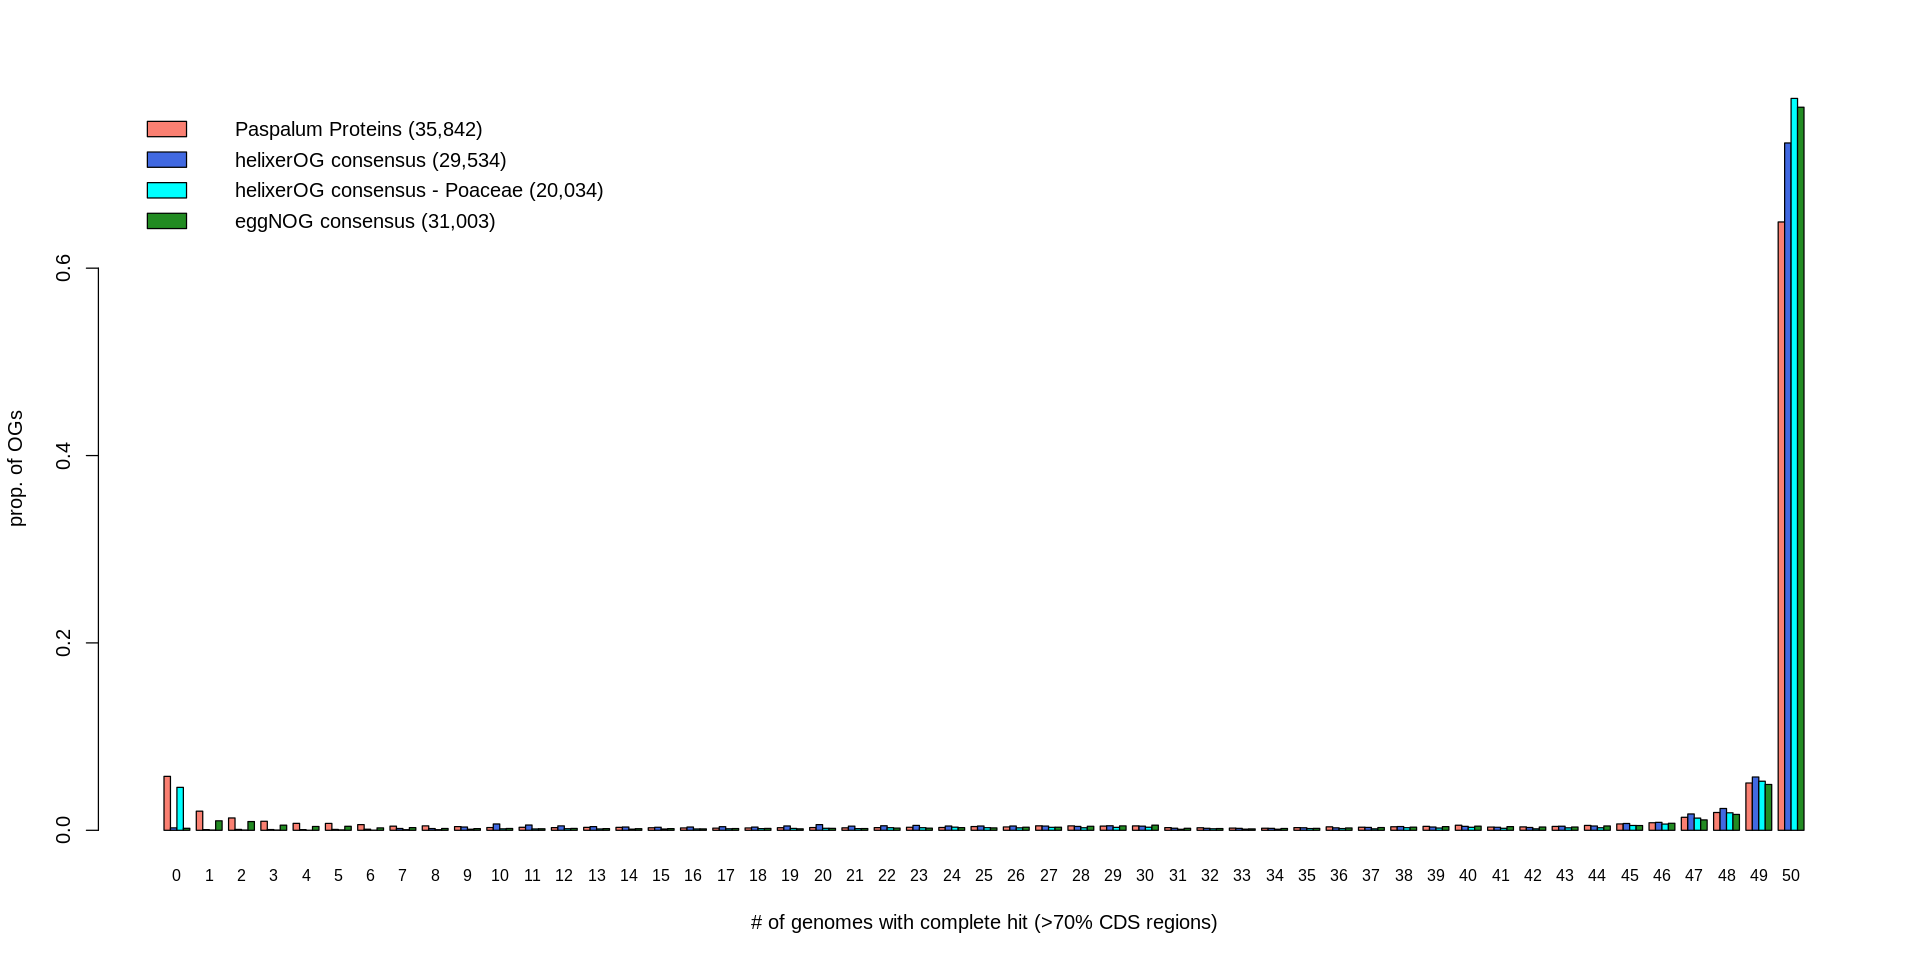

In [201]:
options(repr.plot.width=16, repr.plot.height=8)
barplot(bpDat,beside = T,ylab = "prop. of OGs",
        xlab = "# of genomes with complete hit (>70% CDS regions)",
       col = c("salmon","royalblue","cyan","forestgreen"),cex.name = .8,args.legend = list(bty = 'n',x = "topleft"),
        legend.text = c("Paspalum Proteins (35,842)","helixerOG consensus (29,534)"
                        ,"helixerOG consensus - Poaceae (20,034)","eggNOG consensus (31,003)"))

bpDat
    1     3 
28637   870 

bpDat
         1          3 
0.97051547 0.02948453 

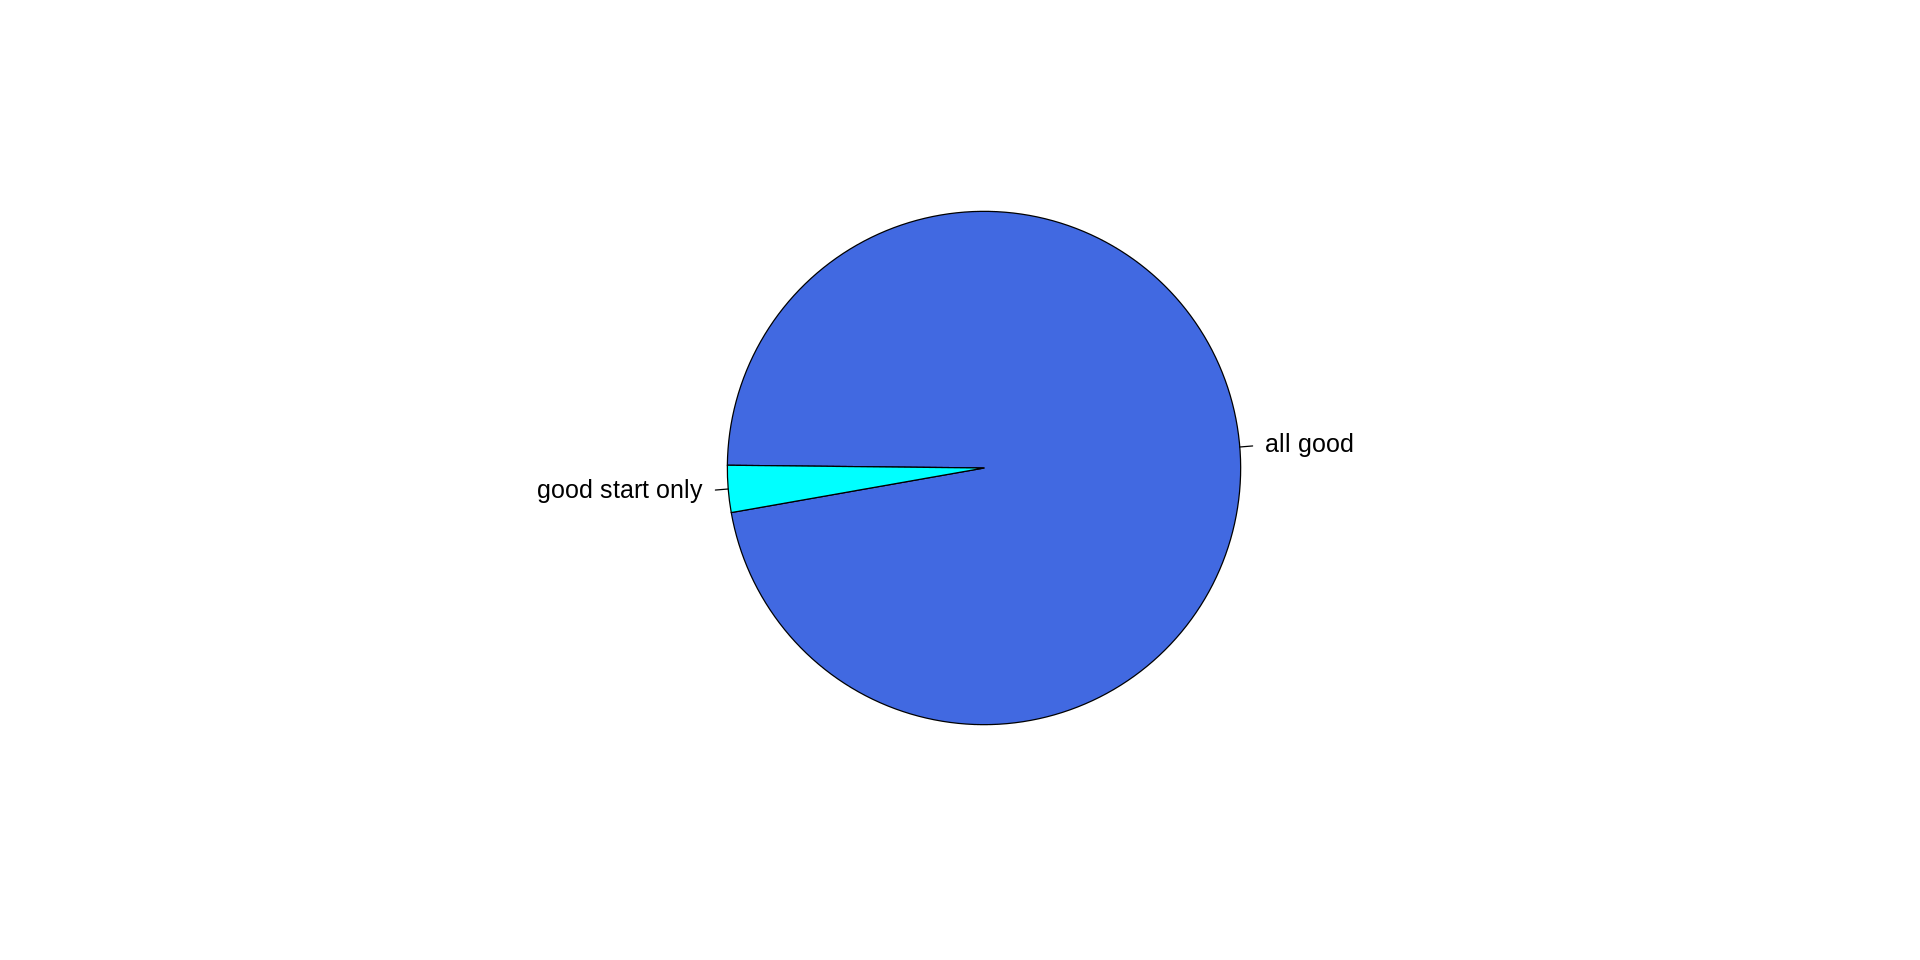

In [61]:
ancAA=readAAStringSet("/workdir/sh2246/p_phyloGWAS/output/HelixerOG_ancSeq_gapRemoved.fa")
ancAA_noEmpty=ancAA[width(ancAA)>0]
idx1=which(sapply(ancAA_noEmpty,function(x) grepl("^m",x)))
idx2=which(sapply(ancAA_noEmpty,function(x) grepl("[*]$",x)))
bpDat=rep(3,length(ancAA_noEmpty))
bpDat[setdiff(idx1,idx2)]=1
bpDat[setdiff(idx2,idx1)]=2
bpDat[intersect(idx2,idx1)]=0
table(bpDat)
table(bpDat)/sum(table(bpDat))
pie(table(bpDat),labels = c("all good","good start only", "good stop only","all bad"),
    cex=1.25,radius = 0.75,init.angle = 190,
    col = c("royalblue","cyan","forestgreen","red"))                  

bpDat
    1     3 
29114  1483 

bpDat
        1         3 
0.9515312 0.0484688 

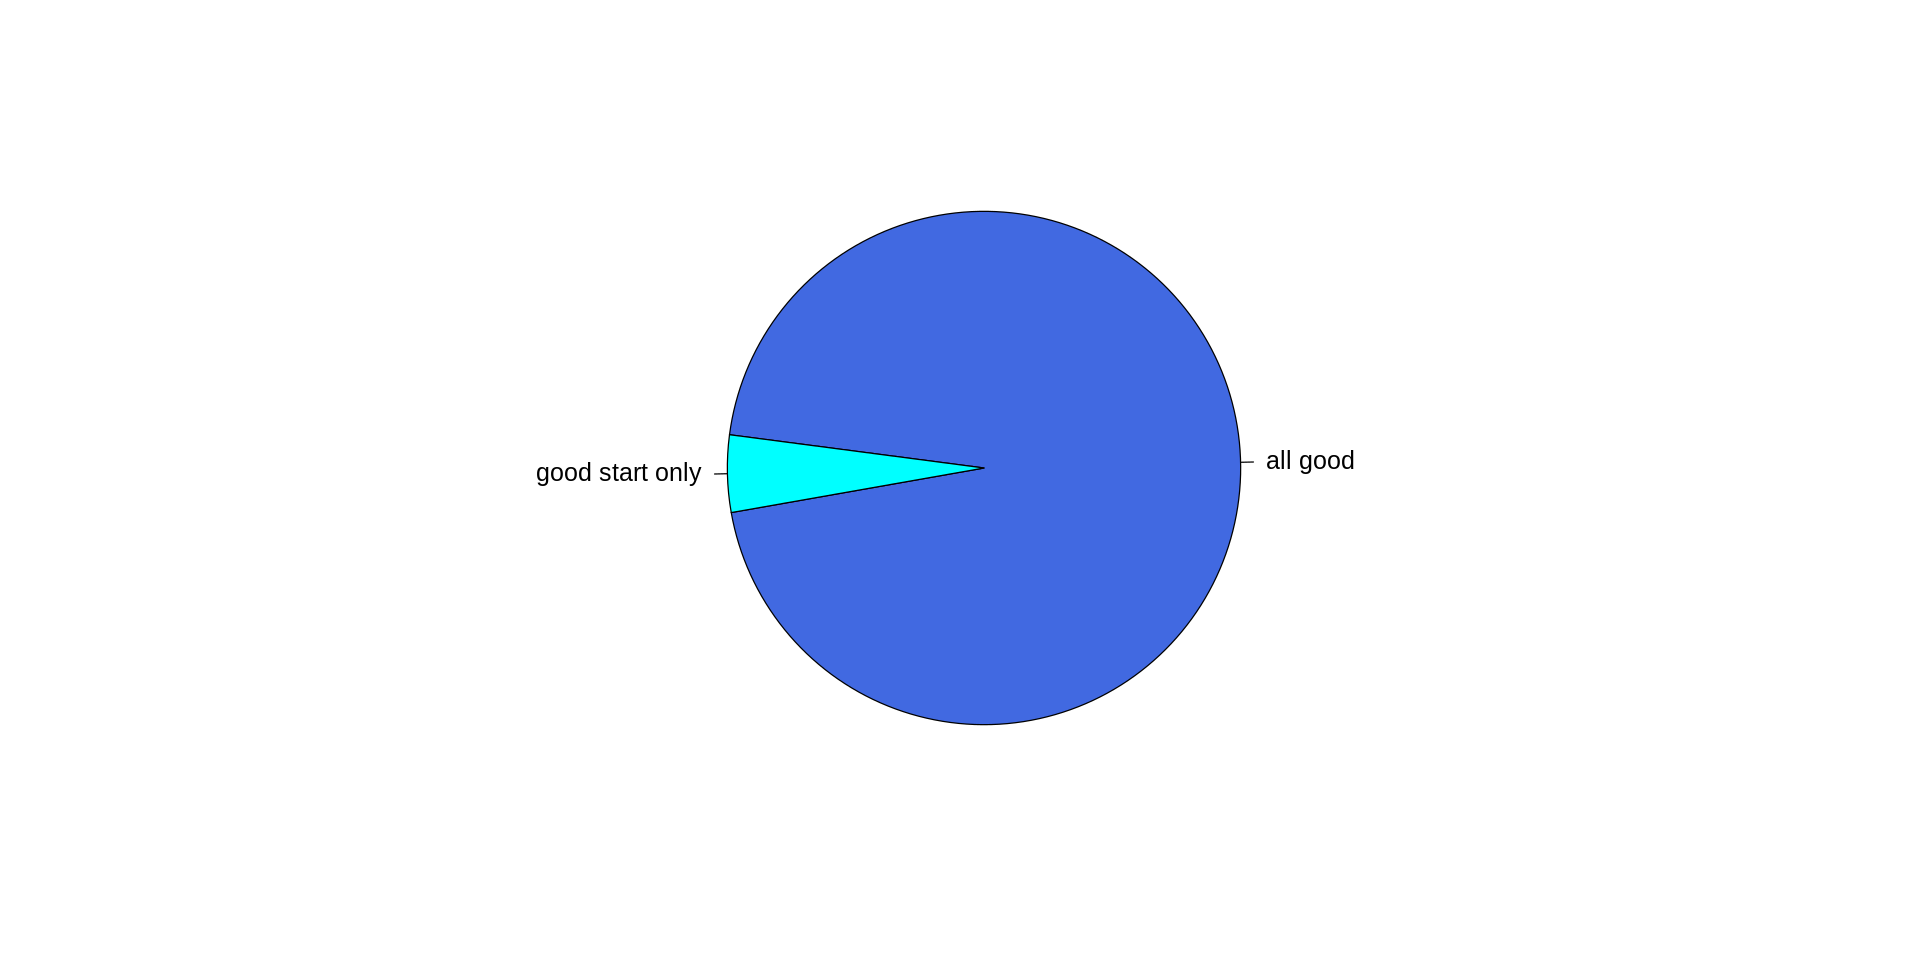

In [164]:
ancAA=readAAStringSet("/workdir/sh2246/p_phyloGWAS/output/poaceaeHelixerOG_ancSeq_gapRemoved.fa")
ancAA_noEmpty=ancAA[width(ancAA)>0]
idx1=which(sapply(ancAA_noEmpty,function(x) grepl("^m",x)))
idx2=which(sapply(ancAA_noEmpty,function(x) grepl("[*]$",x)))
bpDat=rep(3,length(ancAA_noEmpty))
bpDat[setdiff(idx1,idx2)]=1
bpDat[setdiff(idx2,idx1)]=2
bpDat[intersect(idx2,idx1)]=0
table(bpDat)
table(bpDat)/sum(table(bpDat))
pie(table(bpDat),labels = c("all good","good start only", "good stop only","all bad"),
    cex=1.25,radius = 0.75,init.angle = 190,
    col = c("royalblue","cyan","forestgreen","red"))                  

bpDat
    3 
30998 

bpDat
3 
1 

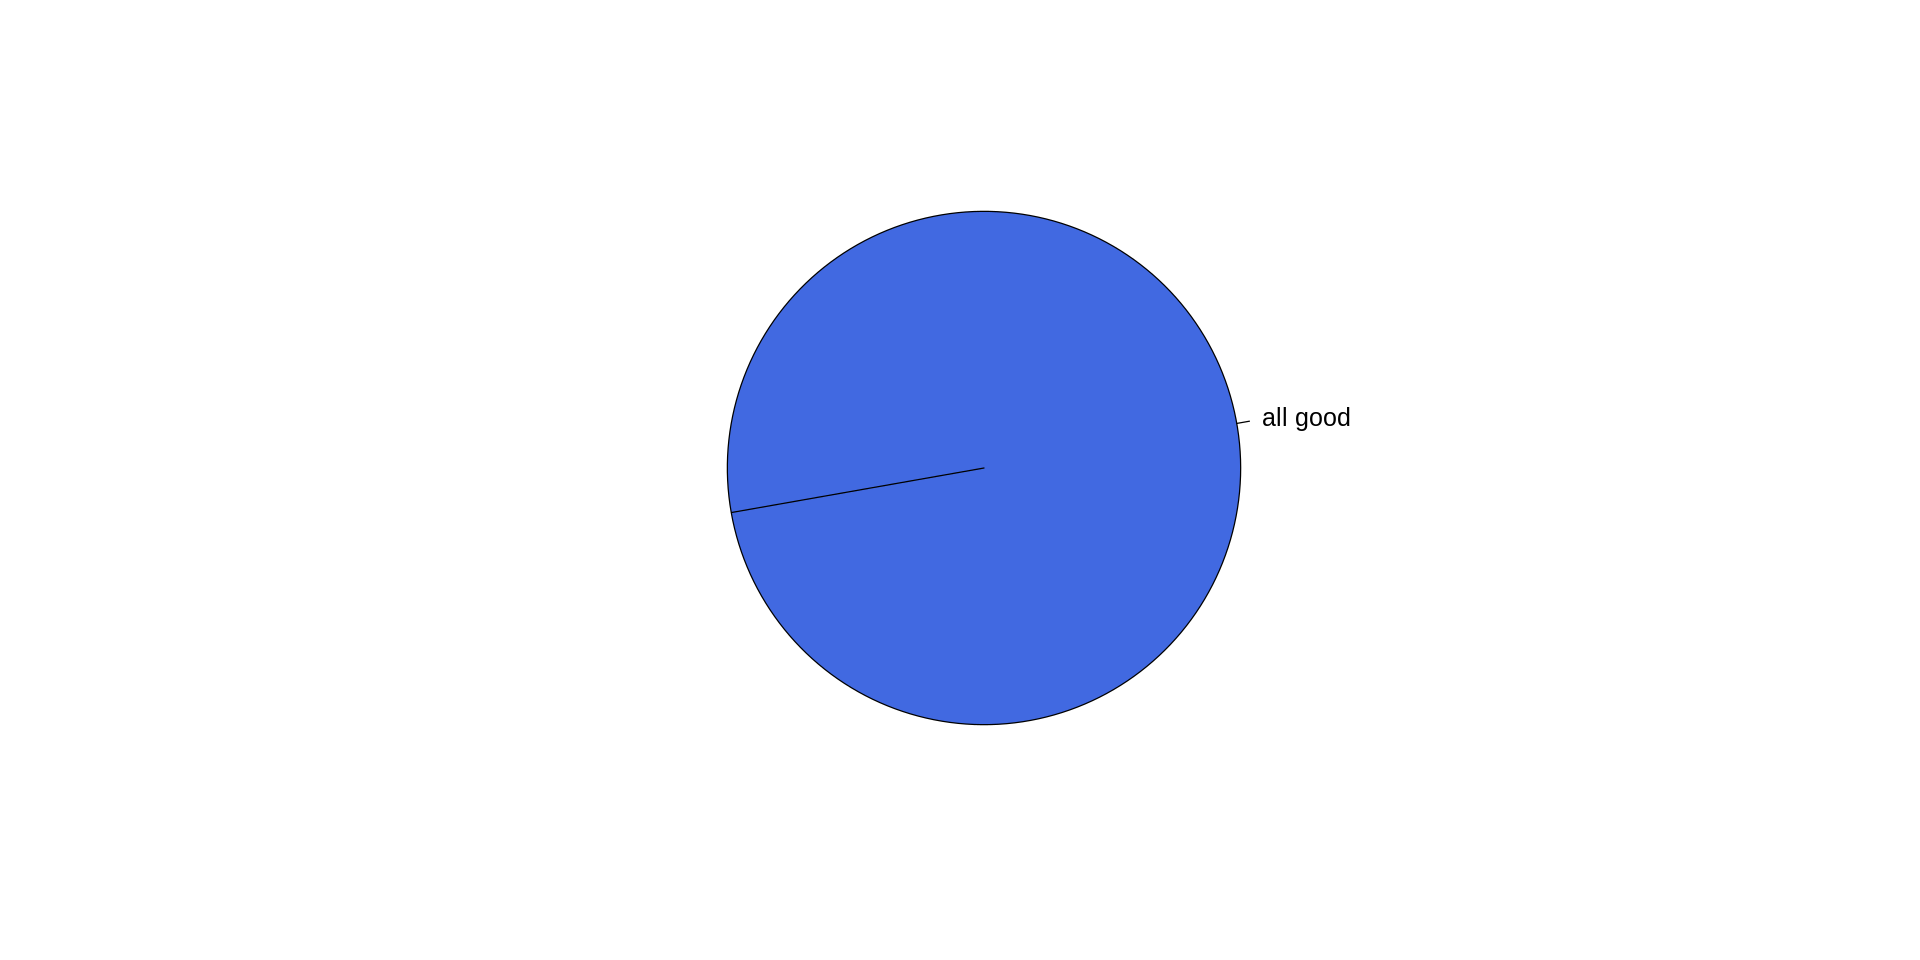

In [65]:
ancAA=readAAStringSet("/workdir/sh2246/p_phyloGWAS/output/eggNOGv5_consensus.fa")
ancAA_noEmpty=ancAA[width(ancAA)>0]
idx1=which(sapply(ancAA_noEmpty,function(x) grepl("^m",x)))
idx2=which(sapply(ancAA_noEmpty,function(x) grepl("[*]$",x)))
bpDat=rep(3,length(ancAA_noEmpty))
bpDat[setdiff(idx1,idx2)]=1
bpDat[setdiff(idx2,idx1)]=2
bpDat[intersect(idx2,idx1)]=0
table(bpDat)
table(bpDat)/sum(table(bpDat))
pie(table(bpDat),labels = c("all good","good start only", "good stop only","all bad"),
    cex=1.25,radius = 0.75,init.angle = 190,
    col = c("royalblue","cyan","forestgreen","red"))                  

bpDat
    3 
45843 

bpDat
3 
1 

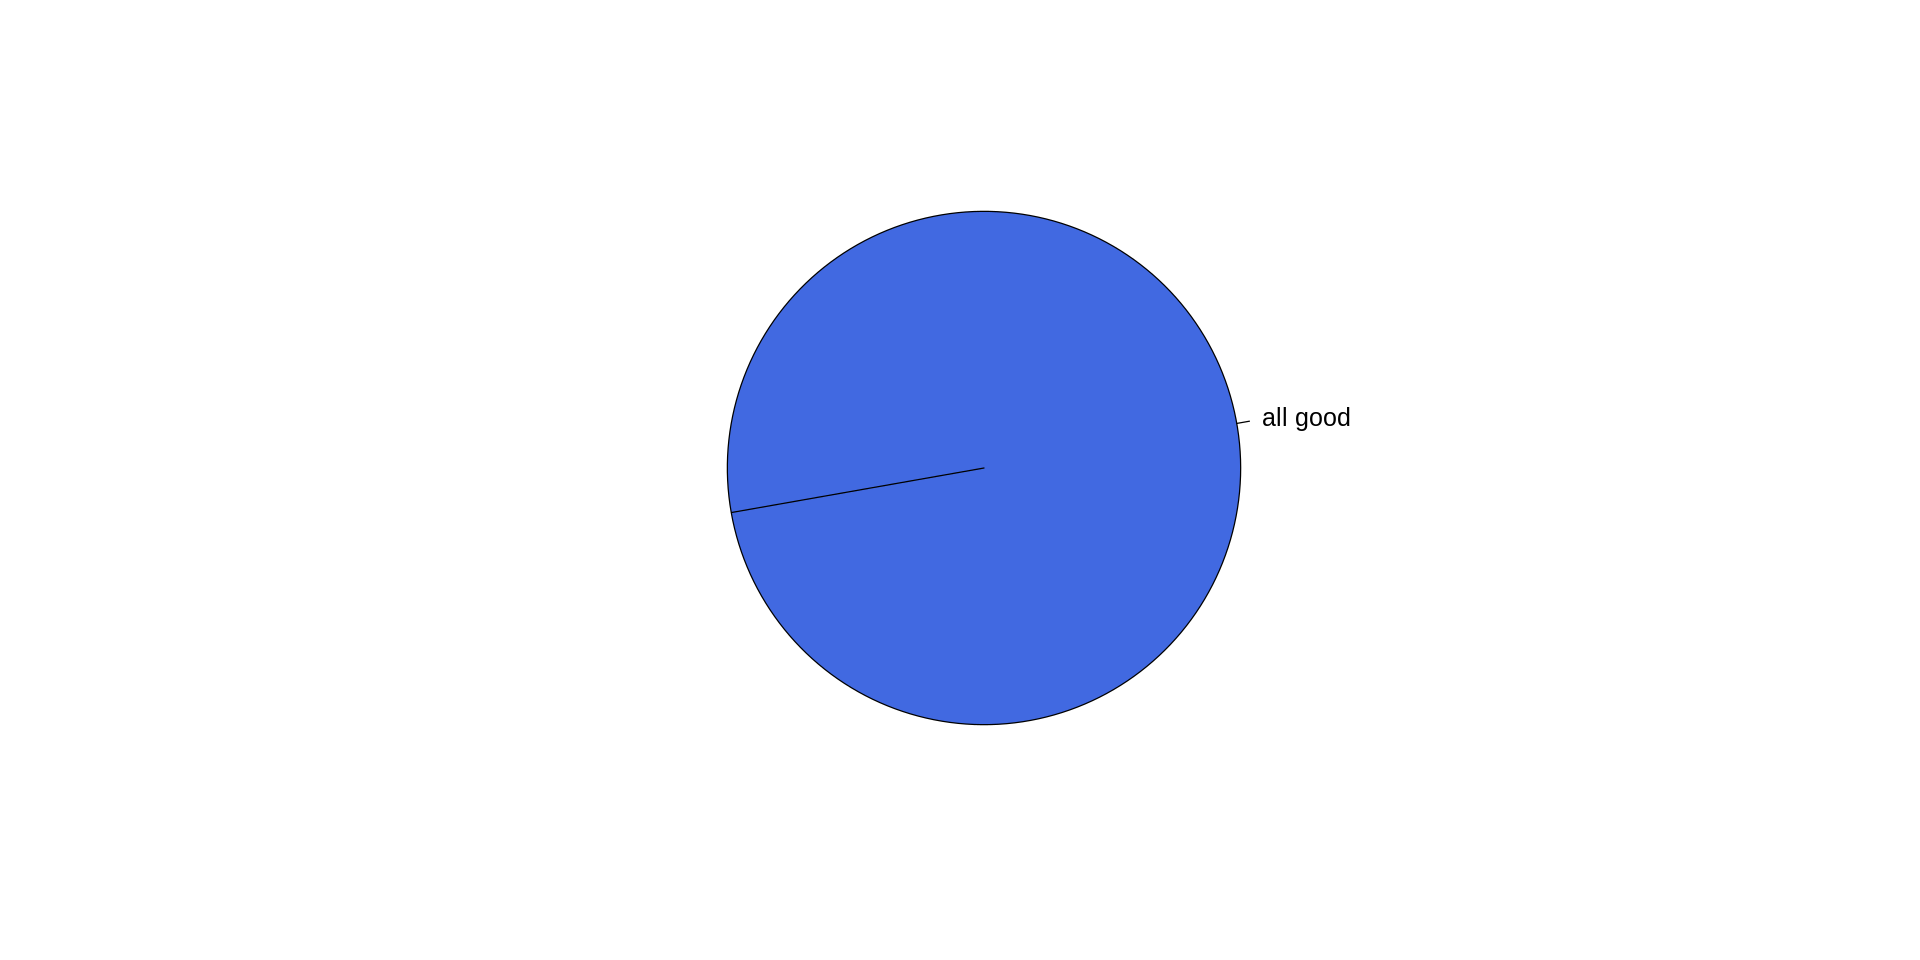

In [66]:
ancAA=readAAStringSet("/workdir/sh2246/p_phyloGWAS/output/Pv-672_v3.0_peptide.fa")
ancAA_noEmpty=ancAA[width(ancAA)>0]
idx1=which(sapply(ancAA_noEmpty,function(x) grepl("^m",x)))
idx2=which(sapply(ancAA_noEmpty,function(x) grepl("[*]$",x)))
bpDat=rep(3,length(ancAA_noEmpty))
bpDat[setdiff(idx1,idx2)]=1
bpDat[setdiff(idx2,idx1)]=2
bpDat[intersect(idx2,idx1)]=0
table(bpDat)
table(bpDat)/sum(table(bpDat))
pie(table(bpDat),labels = c("all good","good start only", "good stop only","all bad"),
    cex=1.25,radius = 0.75,init.angle = 190,
    col = c("royalblue","cyan","forestgreen","red"))                  

# ATG diagnosis


FALSE  TRUE 
 7774 30073 


FALSE  TRUE 
 1620  6154 

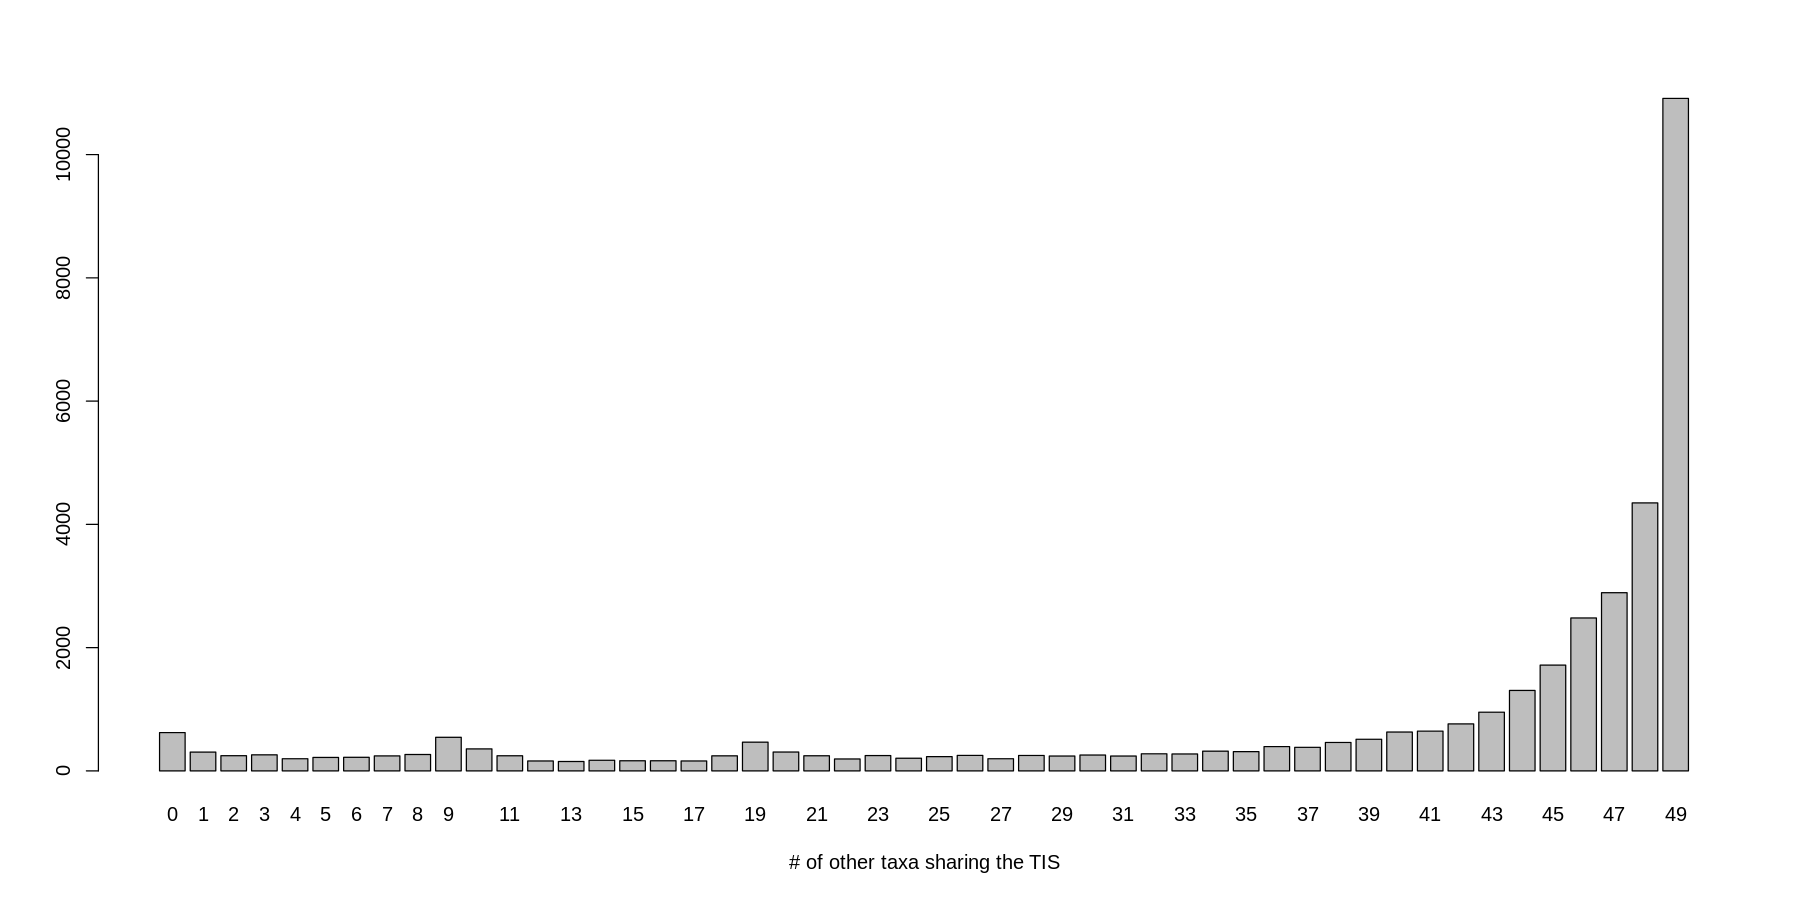

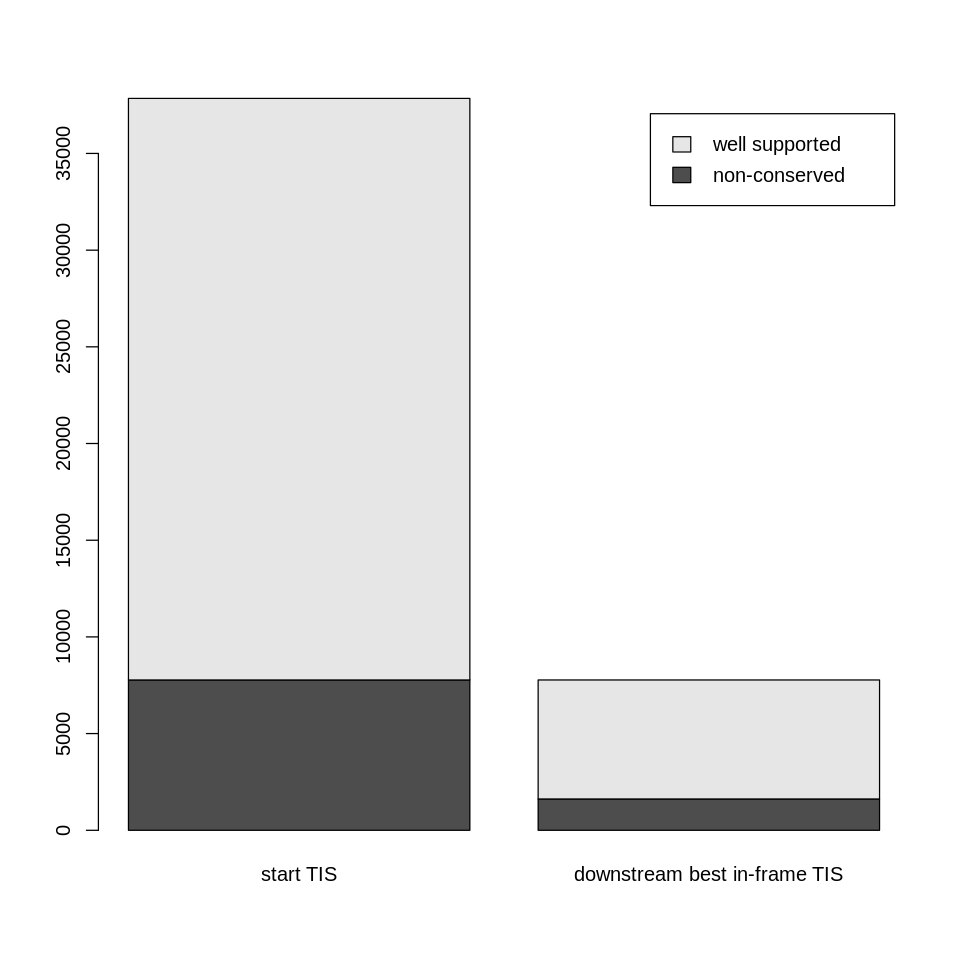

In [115]:
# load 'ATG' profiles
dat_flist = list.files("/workdir/sh2246/p_phyloGWAS/output/queryComparison/ATGProfile_Pv/",full.names = T)
dat_list = mclapply(dat_flist,function(x) read.table(x,header = T,sep = "\t"),mc.cores = 30)
names(dat_list) = gsub(".atgProfile.txt","",strsplit2(dat_flist,"/")[,ncol(strsplit2(dat_flist,"/"))])

# examine the conservation of starting 'ATG'
options(repr.plot.width=15, repr.plot.height=7.5)
firstATGConservation = sapply(dat_list, function(x) x[1,2])
firstATGConservation = na.omit(firstATGConservation)
barplot(table(firstATGConservation),xlab = "# of other taxa sharing the TIS")
# length(firstATGConservation)
# table(firstATGConservation)

# examine the conservation of downstream in-frame 'ATG'
secondInFrameATGConservation = sapply(dat_list[which(!is.na(firstATGConservation))], function(x){
    tmp = x
    tmp = tmp[tmp[,3]%%3 == 0,]
    return(tmp[order(tmp[,2],decreasing = T)[1],2])
})
secondInFrameATGConservation[is.na(secondInFrameATGConservation)]=0                              
# barplot(table(secondInFrameATGConservation),xlab = "# of other taxa sharing the TIS")
# length(secondInFrameATGConservation)
# table(secondInFrameATGConservation)

options(repr.plot.width=8, repr.plot.height=8)
table(firstATGConservation>=30)
table(secondInFrameATGConservation[firstATGConservation<30]>=30)
bpDat1 = cbind(table(firstATGConservation>=30),table(secondInFrameATGConservation[firstATGConservation<30]>=30))
barplot(bpDat1,names.arg = c("start TIS","downstream best in-frame TIS"),legend.text = c("non-conserved","well supported"))


FALSE  TRUE 
 4323 22645 


FALSE  TRUE 
  930  3393 

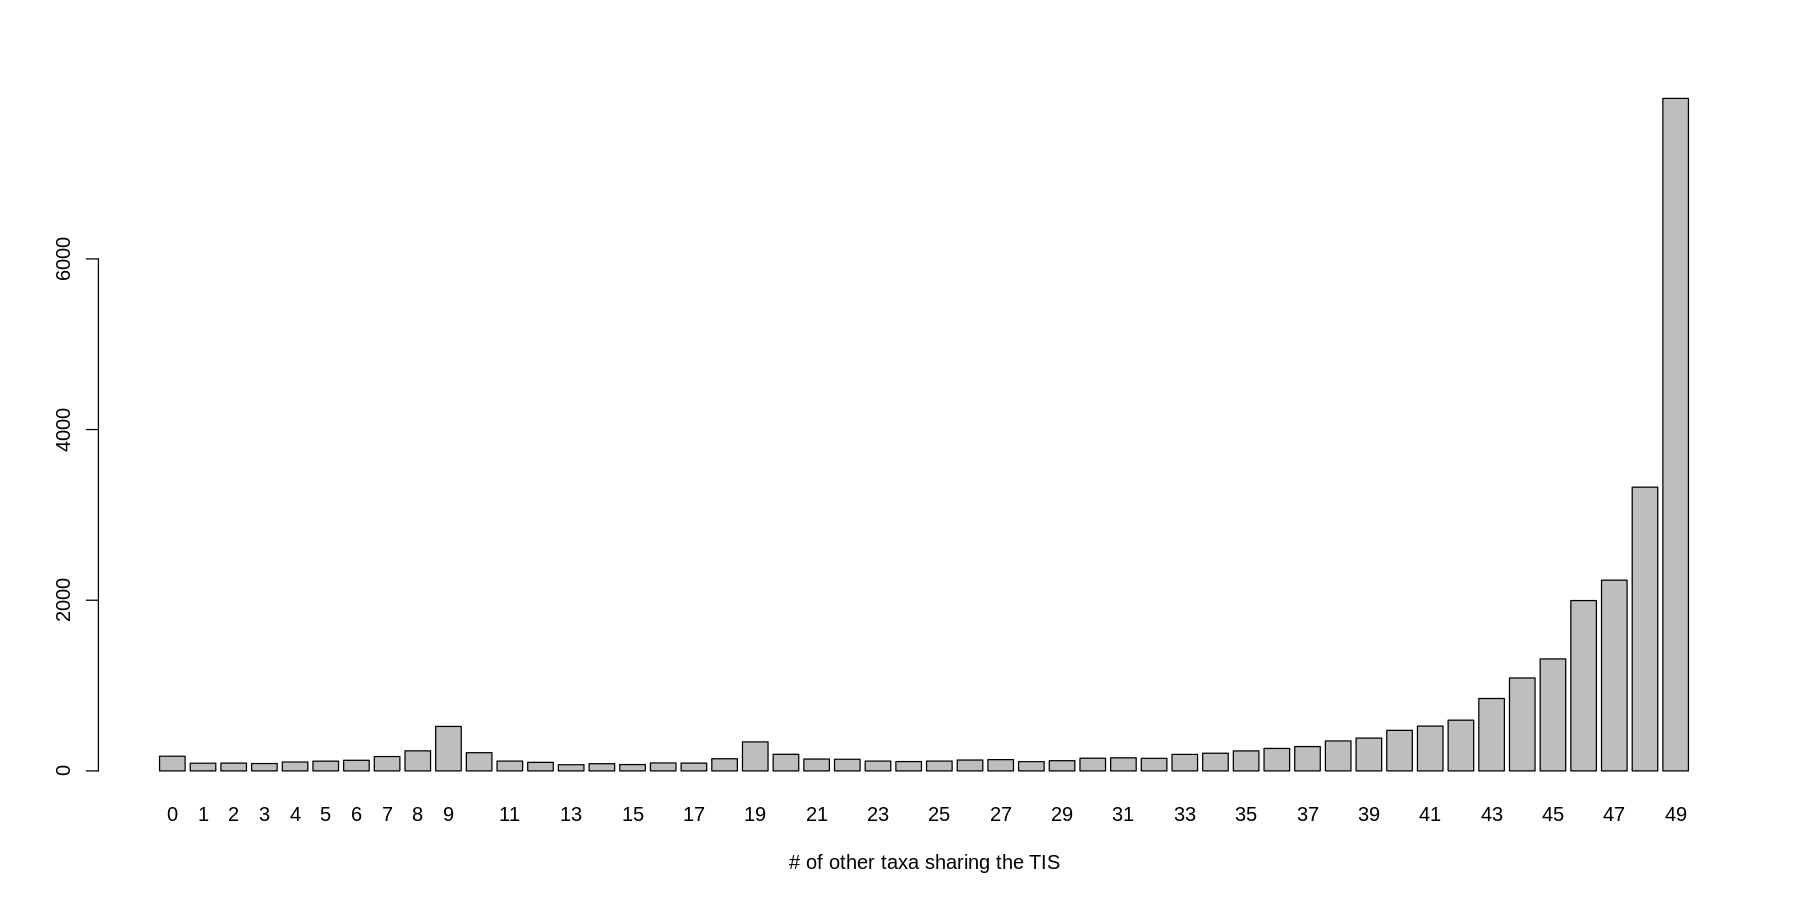

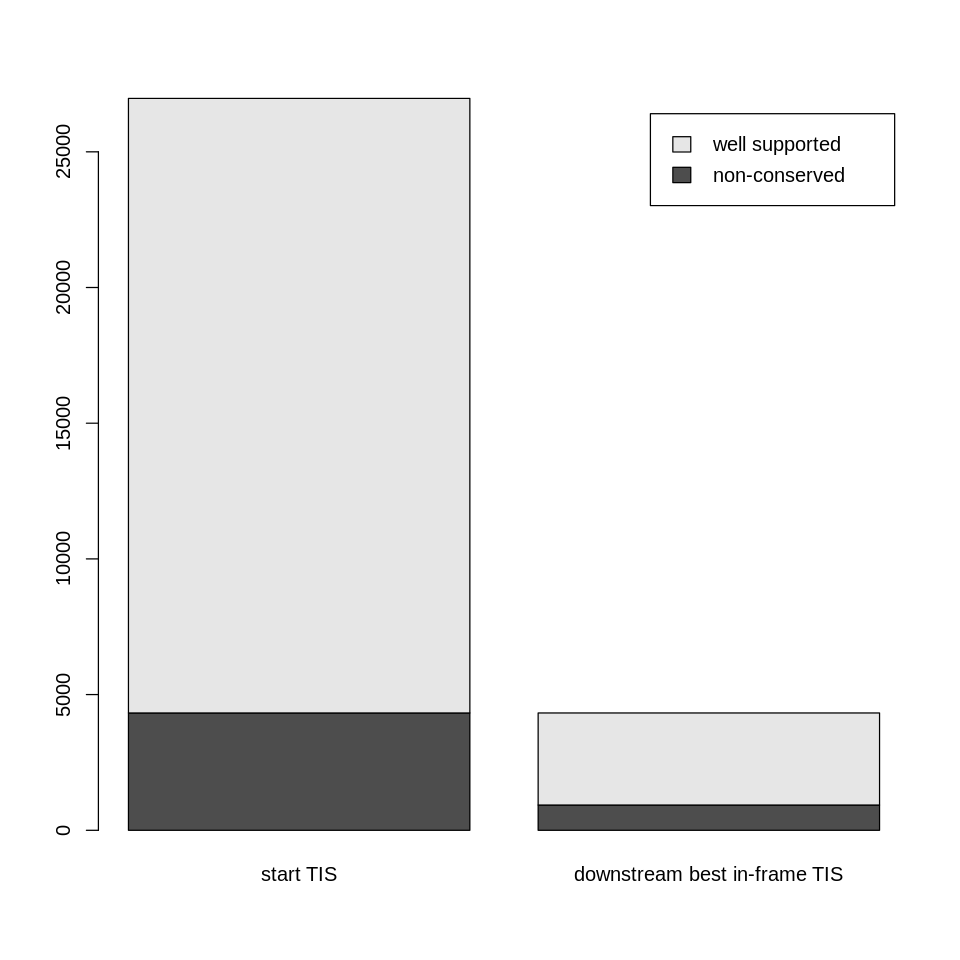

In [116]:
# load 'ATG' profiles
dat_flist = list.files("/workdir/sh2246/p_phyloGWAS/output/queryComparison/ATGProfile_helixerOG/",full.names = T)
dat_list = mclapply(dat_flist,function(x) read.table(x,header = T,sep = "\t"),mc.cores = 30)
names(dat_list) = gsub(".atgProfile.txt","",strsplit2(dat_flist,"/")[,ncol(strsplit2(dat_flist,"/"))])

# examine the conservation of starting 'ATG'
options(repr.plot.width=15, repr.plot.height=7.5)
firstATGConservation = sapply(dat_list, function(x) x[1,2])
firstATGConservation = na.omit(firstATGConservation)
barplot(table(firstATGConservation),xlab = "# of other taxa sharing the TIS")
# length(firstATGConservation)
# table(firstATGConservation)

# examine the conservation of downstream in-frame 'ATG'
secondInFrameATGConservation = sapply(dat_list[which(!is.na(firstATGConservation))], function(x){
    tmp = x
    tmp = tmp[tmp[,3]%%3 == 0,]
    return(tmp[order(tmp[,2],decreasing = T)[1],2])
})
secondInFrameATGConservation[is.na(secondInFrameATGConservation)]=0
# barplot(table(secondInFrameATGConservation),xlab = "# of other taxa sharing the TIS")
# length(secondInFrameATGConservation)
# table(secondInFrameATGConservation)

options(repr.plot.width=8, repr.plot.height=8)
table(firstATGConservation>=30)
table(secondInFrameATGConservation[firstATGConservation<30]>=30)
bpDat2 = cbind(table(firstATGConservation>=30),table(secondInFrameATGConservation[firstATGConservation<30]>=30))
barplot(bpDat2,names.arg = c("start TIS","downstream best in-frame TIS"),legend.text = c("non-conserved","well supported"))


FALSE  TRUE 
 5812 22199 


FALSE  TRUE 
  957  4855 

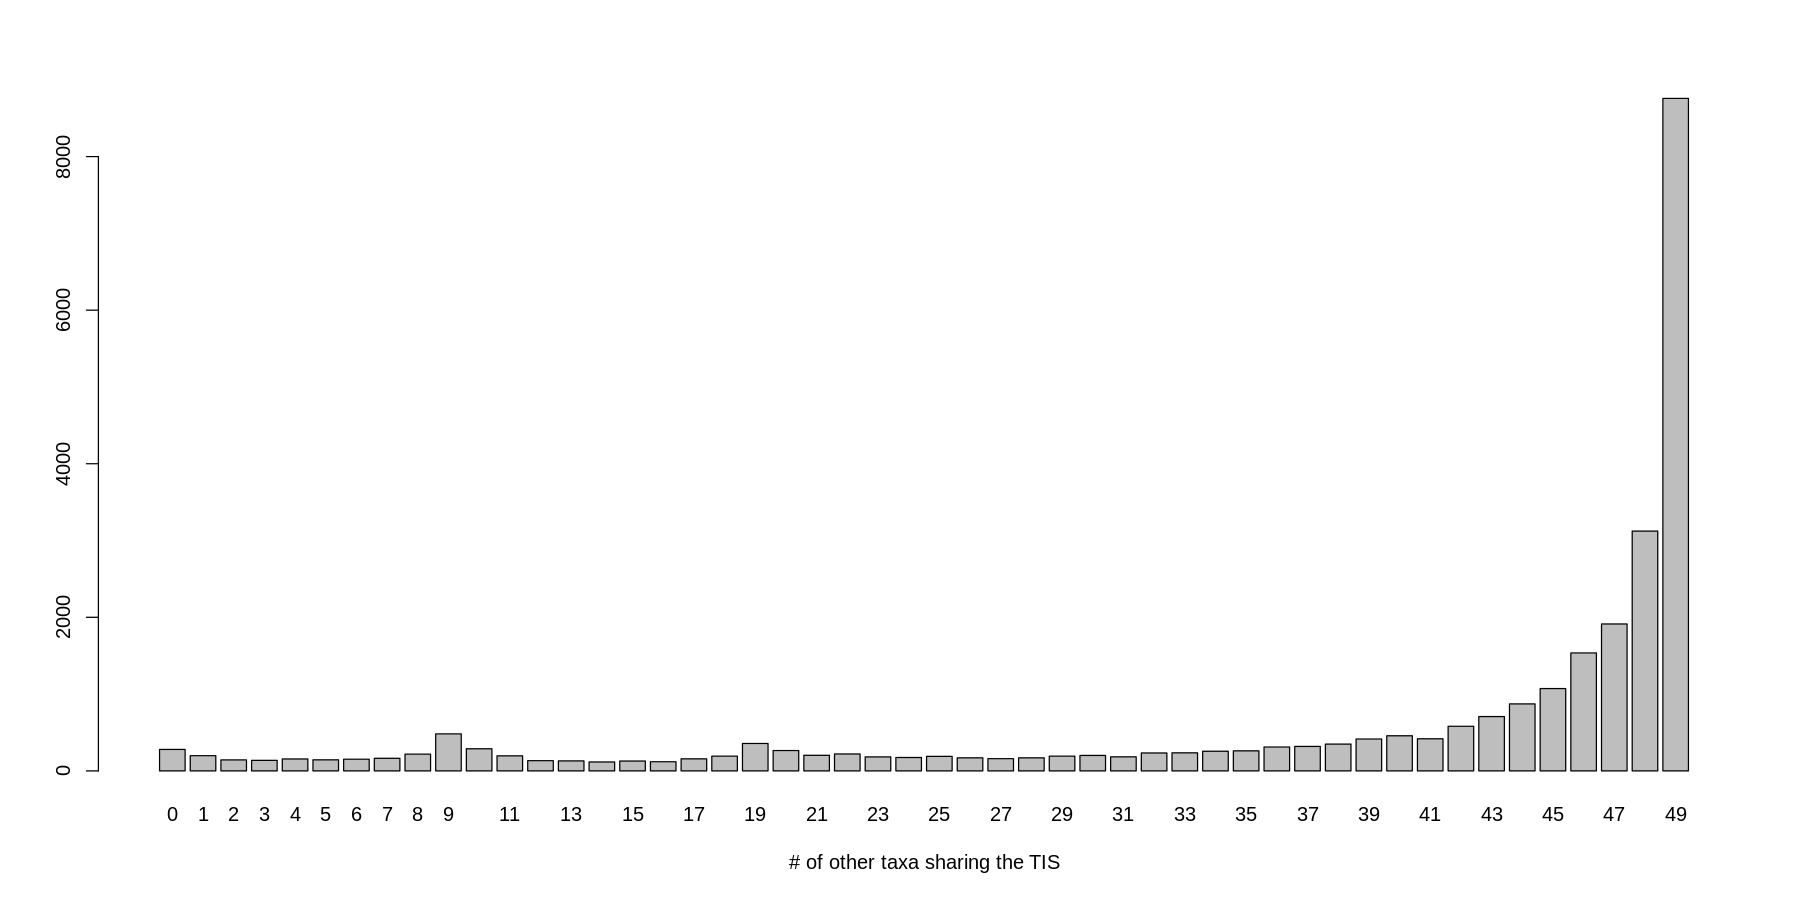

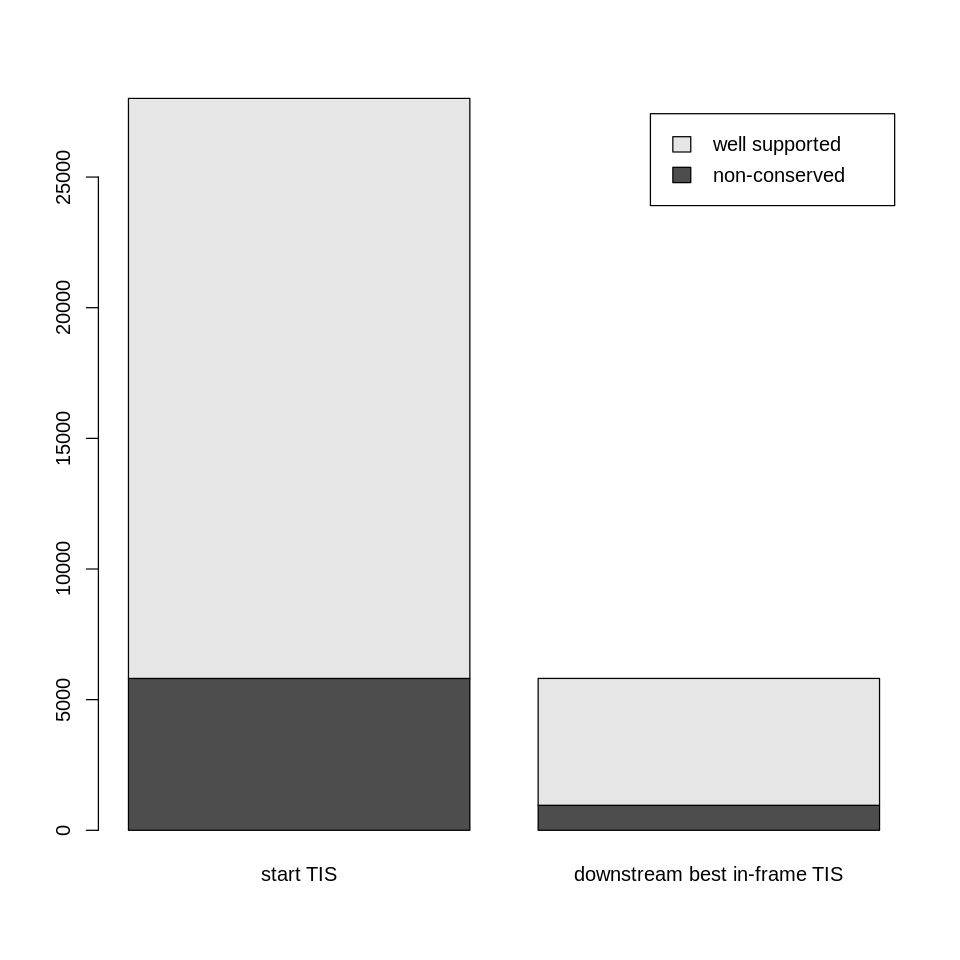

In [117]:
# load 'ATG' profiles
dat_flist = list.files("/workdir/sh2246/p_phyloGWAS/output/queryComparison/ATGProfile_eggNOG/",full.names = T)
dat_list = mclapply(dat_flist,function(x) read.table(x,header = T,sep = "\t"),mc.cores = 30)
names(dat_list) = gsub(".atgProfile.txt","",strsplit2(dat_flist,"/")[,ncol(strsplit2(dat_flist,"/"))])

# examine the conservation of starting 'ATG'
options(repr.plot.width=15, repr.plot.height=7.5)
firstATGConservation = sapply(dat_list, function(x) x[1,2])
firstATGConservation = na.omit(firstATGConservation)
barplot(table(firstATGConservation),xlab = "# of other taxa sharing the TIS")
# length(firstATGConservation)
# table(firstATGConservation)

# examine the conservation of downstream in-frame 'ATG'
secondInFrameATGConservation = sapply(dat_list[which(!is.na(firstATGConservation))], function(x){
    tmp = x
    tmp = tmp[tmp[,3]%%3 == 0,]
    return(tmp[order(tmp[,2],decreasing = T)[1],2])
})
secondInFrameATGConservation[is.na(secondInFrameATGConservation)]=0
# barplot(table(secondInFrameATGConservation),xlab = "# of other taxa sharing the TIS")
# length(secondInFrameATGConservation)
# table(secondInFrameATGConservation)

options(repr.plot.width=8, repr.plot.height=8)
table(firstATGConservation>=30)
table(secondInFrameATGConservation[firstATGConservation<30]>=30)
bpDat3 = cbind(table(firstATGConservation>=30),table(secondInFrameATGConservation[firstATGConservation<30]>=30))
barplot(bpDat3,names.arg = c("start TIS","downstream best in-frame TIS"),legend.text = c("non-conserved","well supported"))

In [118]:
length(firstATGConservation)
length(secondInFrameATGConservation)
length(secondInFrameATGConservation[firstATGConservation<30])
sum(is.na(firstATGConservation))
sum(is.na(secondInFrameATGConservation[firstATGConservation<30]))

[1] 28011

[1] 28011

[1] 5812

[1] 0

[1] 0

In [127]:
secondInFrameATGConservedCoord = sapply(dat_list[which(!is.na(firstATGConservation))], function(x){
    tmp = x
    tmp = tmp[tmp[,3]%%3 == 0,]
    return(tmp[order(tmp[,2],decreasing = T)[1],3])
})


[1] 5812

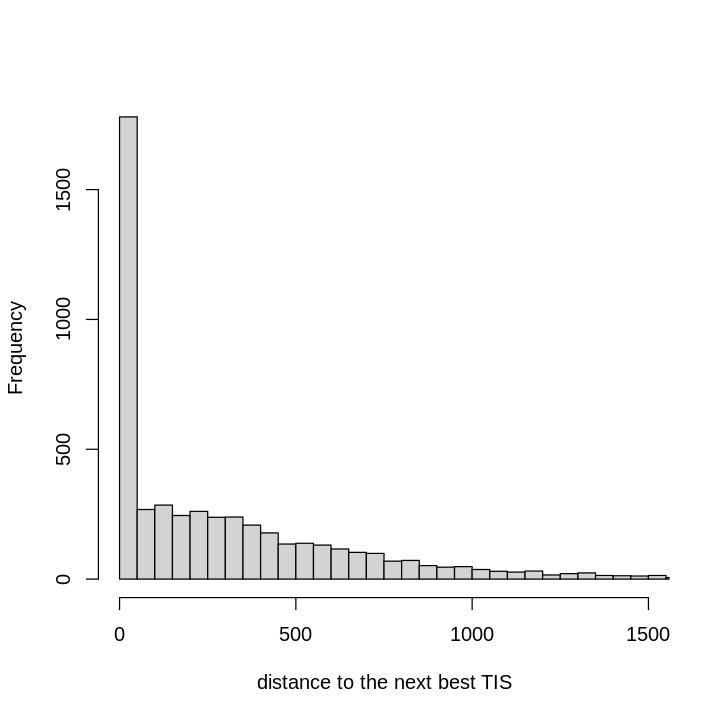

In [140]:
options(repr.plot.width=6, repr.plot.height=6)
length(secondInFrameATGConservedCoord[which(firstATGConservation<30)])
hist(secondInFrameATGConservedCoord[which(firstATGConservation<30)],breaks = seq(0,6000,50),
     xlim = c(0,1500),xlab = "distance to the next best TIS",main = "")

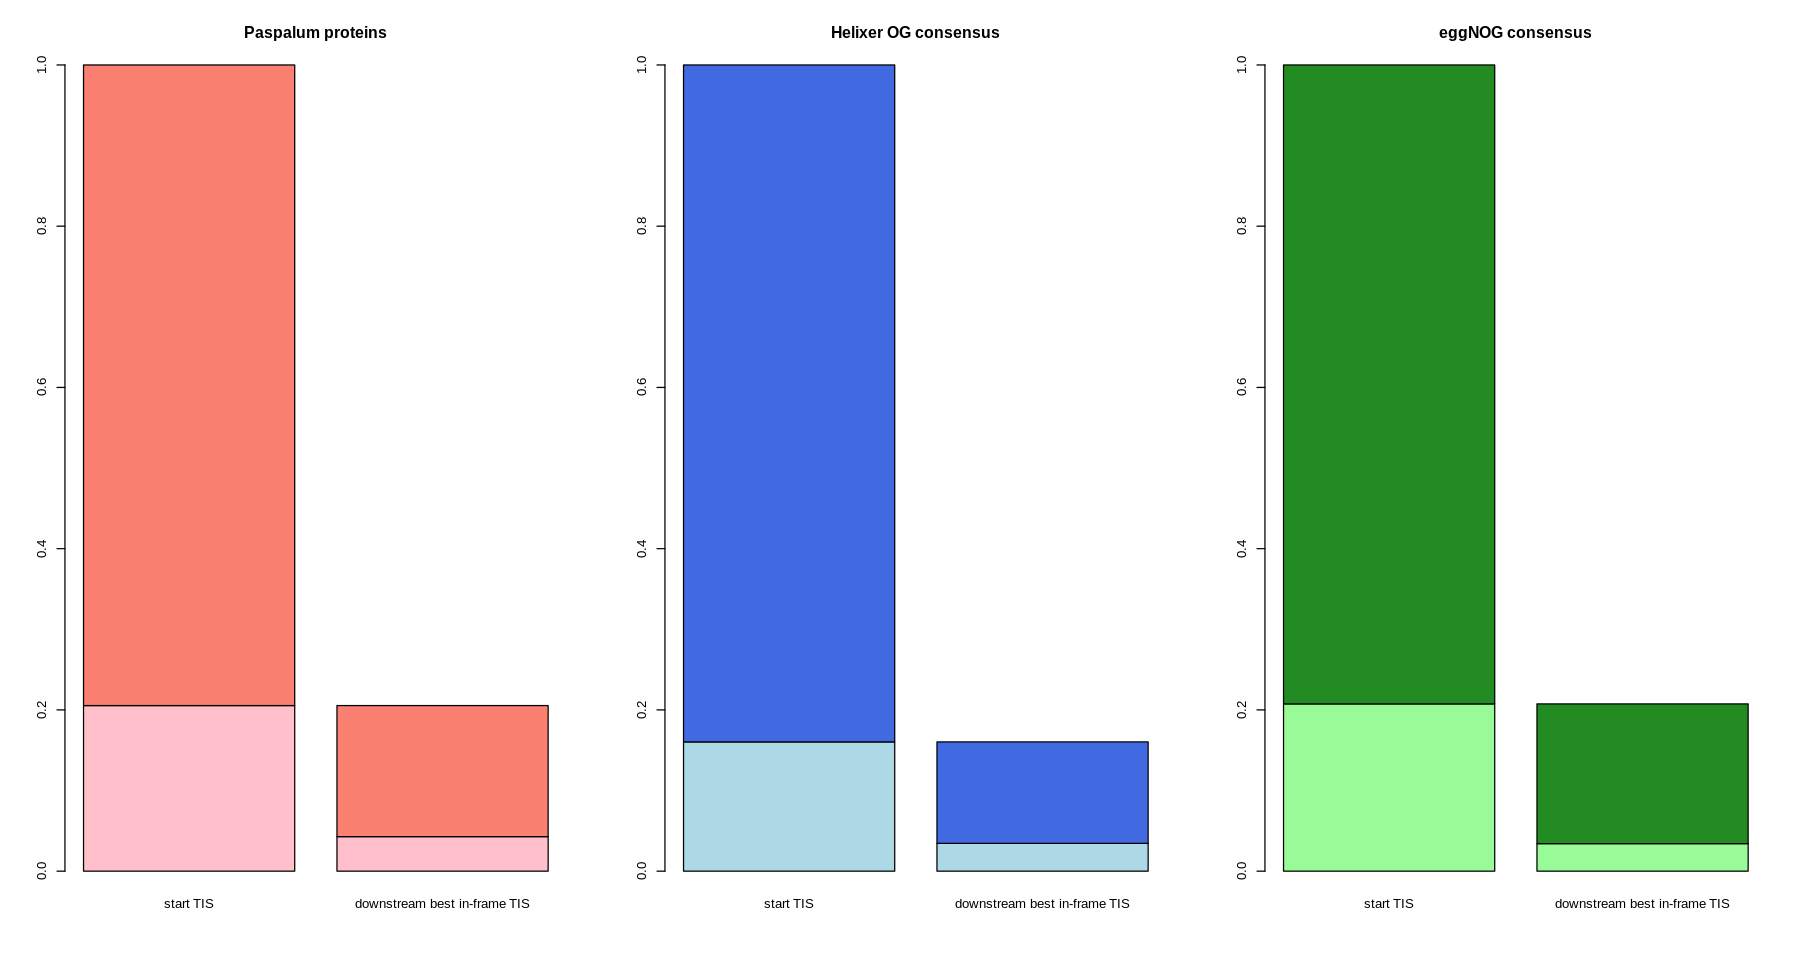

In [119]:
options(repr.plot.width=15, repr.plot.height=8)
par(mfrow= c(1,3))
barplot(bpDat1/37847,names.arg = c("start TIS","downstream best in-frame TIS"),main = "Paspalum proteins",
        col = c("pink","salmon"))
barplot(bpDat2/26968,names.arg = c("start TIS","downstream best in-frame TIS"),main = "Helixer OG consensus",
        col = c("lightblue","royalblue"))
barplot(bpDat3/28011,names.arg = c("start TIS","downstream best in-frame TIS"),main = "eggNOG consensus",
        col = c("palegreen","forestgreen"))

In [120]:
bpDat1/37847
bpDat2/26968
bpDat3/28011

FALSE,0.205406,0.04280392
TRUE,0.794594,0.16260206


FALSE,0.1603011,0.03448532
TRUE,0.8396989,0.12581578


FALSE,0.2074899,0.03416515
TRUE,0.7925101,0.17332477
